In [1]:
import pandas as pd
from scipy.stats import alpha

df=pd.read_csv("IPL_Matches_With_Mixed_Variable.csv")
df.head()

,date,season,city,venue,team1,team2,toss_winner,toss_decision,team1_runs,team1_wickets,...,match_referee,umpire1,umpire2,tv_umpire,reserve_umpire,overs_limit,team1_players,team2_players,player_of_match_jersey,playername_jerseyno
0,26-03-2022,2022,Mumbai,"Wankhede Stadium, Mumbai",Chennai Super Kings,Kolkata Knight Riders,Kolkata Knight Riders,field,131.0,5,...,M Nayyar,AK Chaudhary,Nitin Menon,VK Sharma,Chirra Ravikanthreddy,20,"RD Gaikwad, DP Conway, RV Uthappa, AT Rayudu, ...","AM Rahane, VR Iyer, N Rana, SS Iyer, SW Billin...",99.0,UT Yadav_99
1,27-03-2022,2022,Mumbai,"Brabourne Stadium, Mumbai",Mumbai Indians,Delhi Capitals,Delhi Capitals,field,177.0,5,...,Prakash Bhatt,RJ Tucker,HAS Khalid,J Madanagopal,N Pandit,20,"RG Sharma, Ishan Kishan, Anmolpreet Singh, Til...","PP Shaw, TL Seifert, Mandeep Singh, RR Pant, L...",52.0,Kuldeep Yadav_52
2,27-03-2022,2022,Mumbai,"Dr DY Patil Sports Academy, Mumbai",Royal Challengers Bangalore,Punjab Kings,Punjab Kings,field,205.0,2,...,M Nayyar,Nitin Menon,YC Barde,AK Chaudhary,R Pandit,20,"F du Plessis, Anuj Rawat, V Kohli, KD Karthik,...","MA Agarwal, S Dhawan, PBB Rajapaksa, LS Living...",38.0,OF Smith_38
3,28-03-2022,2022,Mumbai,"Wankhede Stadium, Mumbai",Lucknow Super Giants,Gujarat Titans,Gujarat Titans,field,158.0,6,...,DS Manohar,PG Pathak,VK Sharma,RJ Tucker,GR Sadashiv Iyer,20,"KL Rahul, Q de Kock, E Lewis, MK Pandey, DJ Ho...","Shubman Gill, MS Wade, V Shankar, HH Pandya, D...",70.0,Mohammed Shami_70
4,29-03-2022,2022,Pune,"Maharashtra Cricket Association Stadium, Pune",Rajasthan Royals,Sunrisers Hyderabad,Sunrisers Hyderabad,field,210.0,6,...,Shakti Singh,BNJ Oxenford,UV Gandhe,KN Ananthapadmanabhan,MV Saidharshan Kumar,20,"JC Buttler, YBK Jaiswal, SV Samson, D Padikkal...","KS Williamson, Abhishek Sharma, RA Tripathi, N...",78.0,SV Samson_78


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   date                    367 non-null    str    
 1   season                  367 non-null    int64  
 2   city                    367 non-null    str    
 3   venue                   367 non-null    str    
 4   team1                   367 non-null    str    
 5   team2                   367 non-null    str    
 6   toss_winner             367 non-null    str    
 7   toss_decision           367 non-null    str    
 8   team1_runs              358 non-null    float64
 9   team1_wickets           367 non-null    int64  
 10  team2_runs              358 non-null    float64
 11  team2_wickets           367 non-null    int64  
 12  winner                  354 non-null    str    
 13  result_type             367 non-null    str    
 14  win_by_runs             367 non-null    int64  
 15  

In [4]:
df["player_of_match_jersey"]=df["player_of_match_jersey"].astype('Int64')

In [9]:
df[["player_name","jersey_no"]]=df["playername_jerseyno"].str.rsplit("_",n=1,expand=True)
df.drop(columns=['player_of_match_jersey'], inplace=True)
df[["playername_jerseyno","player_name","jersey_no"]].head(10)

,playername_jerseyno,player_name,jersey_no
0,UT Yadav_99,UT Yadav,99
1,Kuldeep Yadav_52,Kuldeep Yadav,52
2,OF Smith_38,OF Smith,38
3,Mohammed Shami_70,Mohammed Shami,70
4,SV Samson_78,SV Samson,78
5,PWH de Silva_24,PWH de Silva,24
6,E Lewis_69,E Lewis,69
7,UT Yadav_99,UT Yadav,99
8,LH Ferguson_3,LH Ferguson,3
9,JC Buttler_77,JC Buttler,77


In [11]:
import numpy as np
df=pd.read_csv("IPL_DateTime_Dataset.csv")
df.head()
df["match_datetime"]=pd.to_datetime(df["match_datetime"])
df.head()

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3,match_datetime
0,1,2008,Bangalore,2008-04-18,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Kolkata Knight Riders,140,0,BB McCullum,M Chinnaswamy Stadium,Asad Rauf,RE Koertzen,NaN,2008-04-18 15:30:00
1,2,2008,Chandigarh,2008-04-19,Chennai Super Kings,Kings XI Punjab,Chennai Super Kings,bat,normal,0,Chennai Super Kings,33,0,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",MR Benson,SL Shastri,NaN,2008-04-19 19:30:00
2,3,2008,Delhi,2008-04-19,Rajasthan Royals,Delhi Daredevils,Rajasthan Royals,bat,normal,0,Delhi Daredevils,0,9,MF Maharoof,Feroz Shah Kotla,Aleem Dar,GA Pratapkumar,NaN,2008-04-19 15:30:00
3,4,2008,Mumbai,2008-04-20,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,normal,0,Royal Challengers Bangalore,0,5,MV Boucher,Wankhede Stadium,SJ Davis,DJ Harper,NaN,2008-04-20 15:30:00
4,5,2008,Kolkata,2008-04-20,Deccan Chargers,Kolkata Knight Riders,Deccan Chargers,bat,normal,0,Kolkata Knight Riders,0,5,DJ Hussey,Eden Gardens,BF Bowden,K Hariharan,NaN,2008-04-20 15:30:00


In [12]:
df["match_datetime"].dt.year

0      2008
1      2008
2      2008
3      2008
4      2008
       ... 
572    2016
573    2016
574    2016
575    2016
576    2016
Name: match_datetime, Length: 577, dtype: int32

In [13]:
df["match_datetime"].dt.month

0      4
1      4
2      4
3      4
4      4
      ..
572    5
573    5
574    5
575    5
576    5
Name: match_datetime, Length: 577, dtype: int32

In [14]:
df["match_datetime"].dt.month_name()

0      April
1      April
2      April
3      April
4      April
       ...  
572      May
573      May
574      May
575      May
576      May
Name: match_datetime, Length: 577, dtype: str

In [15]:
df["match_datetime"].dt.day

0      18
1      19
2      19
3      20
4      20
       ..
572    22
573    24
574    25
575    27
576    29
Name: match_datetime, Length: 577, dtype: int32

In [16]:
df["match_datetime"].dt.day_name()

0         Friday
1       Saturday
2       Saturday
3         Sunday
4         Sunday
         ...    
572       Sunday
573      Tuesday
574    Wednesday
575       Friday
576       Sunday
Name: match_datetime, Length: 577, dtype: str

In [18]:
df[df["match_datetime"].dt.day_name()=="Sunday"]

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3,match_datetime
3,4,2008,Mumbai,2008-04-20,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,normal,0,Royal Challengers Bangalore,0,5,MV Boucher,Wankhede Stadium,SJ Davis,DJ Harper,NaN,2008-04-20 15:30:00
4,5,2008,Kolkata,2008-04-20,Deccan Chargers,Kolkata Knight Riders,Deccan Chargers,bat,normal,0,Kolkata Knight Riders,0,5,DJ Hussey,Eden Gardens,BF Bowden,K Hariharan,NaN,2008-04-20 15:30:00
12,13,2008,Mumbai,2008-04-27,Mumbai Indians,Deccan Chargers,Deccan Chargers,field,normal,0,Deccan Chargers,0,10,AC Gilchrist,Dr DY Patil Sports Academy,Asad Rauf,SL Shastri,NaN,2008-04-27 15:30:00
13,14,2008,Chandigarh,2008-04-27,Delhi Daredevils,Kings XI Punjab,Delhi Daredevils,bat,normal,0,Kings XI Punjab,0,4,SM Katich,"Punjab Cricket Association Stadium, Mohali",RE Koertzen,I Shivram,NaN,2008-04-27 15:30:00
20,21,2008,Hyderabad,2008-05-25,Deccan Chargers,Royal Challengers Bangalore,Deccan Chargers,bat,normal,0,Royal Challengers Bangalore,0,5,R Vinay Kumar,"Rajiv Gandhi International Stadium, Uppal",Asad Rauf,RE Koertzen,NaN,2008-05-25 19:30:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
562,563,2016,Chandigarh,2016-05-15,Kings XI Punjab,Sunrisers Hyderabad,Kings XI Punjab,bat,normal,0,Sunrisers Hyderabad,0,7,HM Amla,"Punjab Cricket Association IS Bindra Stadium, ...",KN Ananthapadmanabhan,M Erasmus,NaN,2016-05-15 15:30:00
563,564,2016,Visakhapatnam,2016-05-15,Mumbai Indians,Delhi Daredevils,Delhi Daredevils,field,normal,0,Mumbai Indians,80,0,KH Pandya,Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket St...,Nitin Menon,CK Nandan,NaN,2016-05-15 15:30:00
571,572,2016,Kolkata,2016-05-22,Kolkata Knight Riders,Sunrisers Hyderabad,Sunrisers Hyderabad,field,normal,0,Kolkata Knight Riders,22,0,YK Pathan,Eden Gardens,KN Ananthapadmanabhan,M Erasmus,NaN,2016-05-22 15:30:00
572,573,2016,Raipur,2016-05-22,Delhi Daredevils,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Royal Challengers Bangalore,0,6,V Kohli,Shaheed Veer Narayan Singh International Stadium,A Nand Kishore,BNJ Oxenford,NaN,2016-05-22 15:30:00


In [20]:
df['is_weekend']=np.where(
    df['match_datetime'].dt.day_name().isin(['Sunday','Saturday']),1,0
)
df['is_weekend']

0      0
1      1
2      1
3      1
4      1
      ..
572    1
573    0
574    0
575    0
576    1
Name: is_weekend, Length: 577, dtype: int64

In [21]:
df['match_datetime'].dt.quarter

0      2
1      2
2      2
3      2
4      2
      ..
572    2
573    2
574    2
575    2
576    2
Name: match_datetime, Length: 577, dtype: int32

In [22]:
df["match_datetime"].dt.hour

0      15
1      19
2      15
3      15
4      15
       ..
572    15
573    19
574    15
575    19
576    15
Name: match_datetime, Length: 577, dtype: int32

In [23]:
df["match_datetime"].dt.time

0      15:30:00
1      19:30:00
2      15:30:00
3      15:30:00
4      15:30:00
         ...   
572    15:30:00
573    19:30:00
574    15:30:00
575    19:30:00
576    15:30:00
Name: match_datetime, Length: 577, dtype: object

In [24]:
df[["player_first_name","player_last_name"]]=df["player_of_match"].str.rsplit(" ",n=1,expand=True)
df[["player_of_match","player_first_name","player_last_name"]].head(10)

,player_of_match,player_first_name,player_last_name
0,BB McCullum,BB,McCullum
1,MEK Hussey,MEK,Hussey
2,MF Maharoof,MF,Maharoof
3,MV Boucher,MV,Boucher
4,DJ Hussey,DJ,Hussey
5,SR Watson,SR,Watson
6,V Sehwag,V,Sehwag
7,ML Hayden,ML,Hayden
8,YK Pathan,YK,Pathan
9,KC Sangakkara,KC,Sangakkara


In [25]:
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv("class_ipl_22-26_dataset.csv")
df.head()

,date,season,city,venue,team1,team2,toss_winner,toss_decision,team1_runs,team1_wickets,...,win_by_wickets,player_of_match,match_referee,umpire1,umpire2,tv_umpire,reserve_umpire,overs_limit,team1_players,team2_players
0,26-03-2022,2022,Mumbai,"Wankhede Stadium, Mumbai",Chennai Super Kings,Kolkata Knight Riders,Kolkata Knight Riders,field,131,5,...,6,UT Yadav,M Nayyar,AK Chaudhary,Nitin Menon,VK Sharma,Chirra Ravikanthreddy,20,"RD Gaikwad, DP Conway, RV Uthappa, AT Rayudu, ...","AM Rahane, VR Iyer, N Rana, SS Iyer, SW Billin..."
1,27-03-2022,2022,Mumbai,"Brabourne Stadium, Mumbai",Mumbai Indians,Delhi Capitals,Delhi Capitals,field,177,5,...,4,Kuldeep Yadav,Prakash Bhatt,RJ Tucker,HAS Khalid,J Madanagopal,N Pandit,20,"RG Sharma, Ishan Kishan, Anmolpreet Singh, Til...","PP Shaw, TL Seifert, Mandeep Singh, RR Pant, L..."
2,27-03-2022,2022,Mumbai,"Dr DY Patil Sports Academy, Mumbai",Royal Challengers Bangalore,Punjab Kings,Punjab Kings,field,205,2,...,5,OF Smith,M Nayyar,Nitin Menon,YC Barde,AK Chaudhary,R Pandit,20,"F du Plessis, Anuj Rawat, V Kohli, KD Karthik,...","MA Agarwal, S Dhawan, PBB Rajapaksa, LS Living..."
3,28-03-2022,2022,Mumbai,"Wankhede Stadium, Mumbai",Lucknow Super Giants,Gujarat Titans,Gujarat Titans,field,158,6,...,5,Mohammed Shami,DS Manohar,PG Pathak,VK Sharma,RJ Tucker,GR Sadashiv Iyer,20,"KL Rahul, Q de Kock, E Lewis, MK Pandey, DJ Ho...","Shubman Gill, MS Wade, V Shankar, HH Pandya, D..."
4,29-03-2022,2022,Pune,"Maharashtra Cricket Association Stadium, Pune",Rajasthan Royals,Sunrisers Hyderabad,Sunrisers Hyderabad,field,210,6,...,0,SV Samson,Shakti Singh,BNJ Oxenford,UV Gandhe,KN Ananthapadmanabhan,MV Saidharshan Kumar,20,"JC Buttler, YBK Jaiswal, SV Samson, D Padikkal...","KS Williamson, Abhishek Sharma, RA Tripathi, N..."


In [26]:
data=df[["team1_runs","team2_runs","team1_wickets","team2_wickets","win_by_wickets"]]
data.head()

,team1_runs,team2_runs,team1_wickets,team2_wickets,win_by_wickets
0,131,133,5,4,6
1,177,179,5,6,4
2,205,208,2,5,5
3,158,161,6,5,5
4,210,149,6,7,0


In [27]:
correlation=data.corr()
correlation

,team1_runs,team2_runs,team1_wickets,team2_wickets,win_by_wickets
team1_runs,1.000000,0.701668,-0.516325,0.388278,-0.395757
team2_runs,0.701668,1.000000,-0.296213,0.011882,0.074071
team1_wickets,-0.516325,-0.296213,1.000000,-0.195583,0.294736
team2_wickets,0.388278,0.011882,-0.195583,1.000000,-0.825107
win_by_wickets,-0.395757,0.074071,0.294736,-0.825107,1.000000


In [28]:
target_cor=correlation["team1_runs"].drop("team1_runs")
target_cor

team2_runs        0.701668
team1_wickets    -0.516325
team2_wickets     0.388278
win_by_wickets   -0.395757
Name: team1_runs, dtype: float64

In [29]:
target_cor=target_cor.reindex(target_cor.sort_values(ascending=False).index)
target_cor

team2_runs        0.701668
team2_wickets     0.388278
win_by_wickets   -0.395757
team1_wickets    -0.516325
Name: team1_runs, dtype: float64

In [32]:
def forward_selection(correlation_series):
    best_feature=correlation_series.idxmax()
    print("selected feature",best_feature)
    correlation_series=correlation_series.drop(best_feature)
    return correlation_series,best_feature

In [33]:
selected=[]
remaining=target_cor.copy()
remaining,feature=forward_selection(remaining)
selected.append(feature)
print("selected feature",selected)
print("remaining feature",remaining)


selected feature team2_runs
selected feature ['team2_runs']
remaining feature team2_wickets     0.388278
win_by_wickets   -0.395757
team1_wickets    -0.516325
Name: team1_runs, dtype: float64


In [34]:
remaining,feature=forward_selection(remaining)
selected.append(feature)
print("selected feature",selected)
print("remaining feature",remaining)

selected feature team2_wickets
selected feature ['team2_runs', 'team2_wickets']
remaining feature win_by_wickets   -0.395757
team1_wickets    -0.516325
Name: team1_runs, dtype: float64


In [35]:
remaining,feature=forward_selection(remaining)
selected.append(feature)
print("selected feature",selected)
print("remaining feature",remaining)

selected feature win_by_wickets
selected feature ['team2_runs', 'team2_wickets', 'win_by_wickets']
remaining feature team1_wickets   -0.516325
Name: team1_runs, dtype: float64


In [36]:
print("selected feature")
selected_df=pd.DataFrame({
    "selected_feature":selected
})
display(selected_df)
print("remaining feature(not selected)",remaining)

selected feature


,selected_feature
0,team2_runs
1,team2_wickets
2,win_by_wickets


remaining feature(not selected) team1_wickets   -0.516325
Name: team1_runs, dtype: float64


In [37]:
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv("class_ipl_22-26_dataset.csv")
df.head()

,date,season,city,venue,team1,team2,toss_winner,toss_decision,team1_runs,team1_wickets,...,win_by_wickets,player_of_match,match_referee,umpire1,umpire2,tv_umpire,reserve_umpire,overs_limit,team1_players,team2_players
0,26-03-2022,2022,Mumbai,"Wankhede Stadium, Mumbai",Chennai Super Kings,Kolkata Knight Riders,Kolkata Knight Riders,field,131,5,...,6,UT Yadav,M Nayyar,AK Chaudhary,Nitin Menon,VK Sharma,Chirra Ravikanthreddy,20,"RD Gaikwad, DP Conway, RV Uthappa, AT Rayudu, ...","AM Rahane, VR Iyer, N Rana, SS Iyer, SW Billin..."
1,27-03-2022,2022,Mumbai,"Brabourne Stadium, Mumbai",Mumbai Indians,Delhi Capitals,Delhi Capitals,field,177,5,...,4,Kuldeep Yadav,Prakash Bhatt,RJ Tucker,HAS Khalid,J Madanagopal,N Pandit,20,"RG Sharma, Ishan Kishan, Anmolpreet Singh, Til...","PP Shaw, TL Seifert, Mandeep Singh, RR Pant, L..."
2,27-03-2022,2022,Mumbai,"Dr DY Patil Sports Academy, Mumbai",Royal Challengers Bangalore,Punjab Kings,Punjab Kings,field,205,2,...,5,OF Smith,M Nayyar,Nitin Menon,YC Barde,AK Chaudhary,R Pandit,20,"F du Plessis, Anuj Rawat, V Kohli, KD Karthik,...","MA Agarwal, S Dhawan, PBB Rajapaksa, LS Living..."
3,28-03-2022,2022,Mumbai,"Wankhede Stadium, Mumbai",Lucknow Super Giants,Gujarat Titans,Gujarat Titans,field,158,6,...,5,Mohammed Shami,DS Manohar,PG Pathak,VK Sharma,RJ Tucker,GR Sadashiv Iyer,20,"KL Rahul, Q de Kock, E Lewis, MK Pandey, DJ Ho...","Shubman Gill, MS Wade, V Shankar, HH Pandya, D..."
4,29-03-2022,2022,Pune,"Maharashtra Cricket Association Stadium, Pune",Rajasthan Royals,Sunrisers Hyderabad,Sunrisers Hyderabad,field,210,6,...,0,SV Samson,Shakti Singh,BNJ Oxenford,UV Gandhe,KN Ananthapadmanabhan,MV Saidharshan Kumar,20,"JC Buttler, YBK Jaiswal, SV Samson, D Padikkal...","KS Williamson, Abhishek Sharma, RA Tripathi, N..."


In [38]:
data=df[["team1_runs","team2_runs","team1_wickets","team2_wickets","win_by_wickets"]]
data.head()

,team1_runs,team2_runs,team1_wickets,team2_wickets,win_by_wickets
0,131,133,5,4,6
1,177,179,5,6,4
2,205,208,2,5,5
3,158,161,6,5,5
4,210,149,6,7,0


In [39]:
correlation=data.corr()
correlation

,team1_runs,team2_runs,team1_wickets,team2_wickets,win_by_wickets
team1_runs,1.000000,0.701668,-0.516325,0.388278,-0.395757
team2_runs,0.701668,1.000000,-0.296213,0.011882,0.074071
team1_wickets,-0.516325,-0.296213,1.000000,-0.195583,0.294736
team2_wickets,0.388278,0.011882,-0.195583,1.000000,-0.825107
win_by_wickets,-0.395757,0.074071,0.294736,-0.825107,1.000000


In [40]:
target_cor=correlation["team1_runs"].drop("team1_runs")
target_cor

team2_runs        0.701668
team1_wickets    -0.516325
team2_wickets     0.388278
win_by_wickets   -0.395757
Name: team1_runs, dtype: float64

In [42]:
target_cor=target_cor.reindex(target_cor.sort_values().index)
target_cor

team1_wickets    -0.516325
win_by_wickets   -0.395757
team2_wickets     0.388278
team2_runs        0.701668
Name: team1_runs, dtype: float64

In [43]:
def backward_elimination(correlation_series):
    least_feature=correlation_series.idxmin()
    print("removed feature",least_feature)
    correlation_series=correlation_series.drop(least_feature)
    return correlation_series,least_feature

In [44]:
remaining=target_cor.copy()
removed=[]
remaining,feature=backward_elimination(remaining)
removed.append(feature)
print("removed feature",removed)
print("remaining feature",remaining)

removed feature team1_wickets
removed feature ['team1_wickets']
remaining feature win_by_wickets   -0.395757
team2_wickets     0.388278
team2_runs        0.701668
Name: team1_runs, dtype: float64


In [45]:
remaining,feature=backward_elimination(remaining)
removed.append(feature)
print("removed feature",removed)
print("remaining feature",remaining)

removed feature win_by_wickets
removed feature ['team1_wickets', 'win_by_wickets']
remaining feature team2_wickets    0.388278
team2_runs       0.701668
Name: team1_runs, dtype: float64


In [46]:
remaining,feature=backward_elimination(remaining)
removed.append(feature)
print("removed feature",removed)
print("remaining feature",remaining)

removed feature team2_wickets
removed feature ['team1_wickets', 'win_by_wickets', 'team2_wickets']
remaining feature team2_runs    0.701668
Name: team1_runs, dtype: float64


In [48]:
selected_df=pd.DataFrame({
    "selected_feature":remaining.index
})
selected_df

,selected_feature
0,team2_runs


principle componenet analysis

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
df = pd.read_csv("class_ipl_22-26_dataset.csv")
df.head()

,date,season,city,venue,team1,team2,toss_winner,toss_decision,team1_runs,team1_wickets,...,win_by_wickets,player_of_match,match_referee,umpire1,umpire2,tv_umpire,reserve_umpire,overs_limit,team1_players,team2_players
0,26-03-2022,2022,Mumbai,"Wankhede Stadium, Mumbai",Chennai Super Kings,Kolkata Knight Riders,Kolkata Knight Riders,field,131,5,...,6,UT Yadav,M Nayyar,AK Chaudhary,Nitin Menon,VK Sharma,Chirra Ravikanthreddy,20,"RD Gaikwad, DP Conway, RV Uthappa, AT Rayudu, ...","AM Rahane, VR Iyer, N Rana, SS Iyer, SW Billin..."
1,27-03-2022,2022,Mumbai,"Brabourne Stadium, Mumbai",Mumbai Indians,Delhi Capitals,Delhi Capitals,field,177,5,...,4,Kuldeep Yadav,Prakash Bhatt,RJ Tucker,HAS Khalid,J Madanagopal,N Pandit,20,"RG Sharma, Ishan Kishan, Anmolpreet Singh, Til...","PP Shaw, TL Seifert, Mandeep Singh, RR Pant, L..."
2,27-03-2022,2022,Mumbai,"Dr DY Patil Sports Academy, Mumbai",Royal Challengers Bangalore,Punjab Kings,Punjab Kings,field,205,2,...,5,OF Smith,M Nayyar,Nitin Menon,YC Barde,AK Chaudhary,R Pandit,20,"F du Plessis, Anuj Rawat, V Kohli, KD Karthik,...","MA Agarwal, S Dhawan, PBB Rajapaksa, LS Living..."
3,28-03-2022,2022,Mumbai,"Wankhede Stadium, Mumbai",Lucknow Super Giants,Gujarat Titans,Gujarat Titans,field,158,6,...,5,Mohammed Shami,DS Manohar,PG Pathak,VK Sharma,RJ Tucker,GR Sadashiv Iyer,20,"KL Rahul, Q de Kock, E Lewis, MK Pandey, DJ Ho...","Shubman Gill, MS Wade, V Shankar, HH Pandya, D..."
4,29-03-2022,2022,Pune,"Maharashtra Cricket Association Stadium, Pune",Rajasthan Royals,Sunrisers Hyderabad,Sunrisers Hyderabad,field,210,6,...,0,SV Samson,Shakti Singh,BNJ Oxenford,UV Gandhe,KN Ananthapadmanabhan,MV Saidharshan Kumar,20,"JC Buttler, YBK Jaiswal, SV Samson, D Padikkal...","KS Williamson, Abhishek Sharma, RA Tripathi, N..."


In [3]:
df.shape

(367, 25)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 25 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   date             367 non-null    str  
 1   season           367 non-null    int64
 2   city             367 non-null    str  
 3   venue            367 non-null    str  
 4   team1            367 non-null    str  
 5   team2            367 non-null    str  
 6   toss_winner      367 non-null    str  
 7   toss_decision    367 non-null    str  
 8   team1_runs       367 non-null    int64
 9   team1_wickets    367 non-null    int64
 10  team2_runs       367 non-null    int64
 11  team2_wickets    367 non-null    int64
 12  winner           360 non-null    str  
 13  result_type      367 non-null    str  
 14  win_by_runs      367 non-null    int64
 15  win_by_wickets   367 non-null    int64
 16  player_of_match  362 non-null    str  
 17  match_referee    367 non-null    str  
 18  umpire1          367 

In [5]:
features=df[["team1_runs","team1_wickets","team2_runs","team2_wickets","win_by_runs","win_by_wickets"]]
x=features
x.head()

,team1_runs,team1_wickets,team2_runs,team2_wickets,win_by_runs,win_by_wickets
0,131,5,133,4,0,6
1,177,5,179,6,0,4
2,205,2,208,5,0,5
3,158,6,161,5,0,5
4,210,6,149,7,61,0


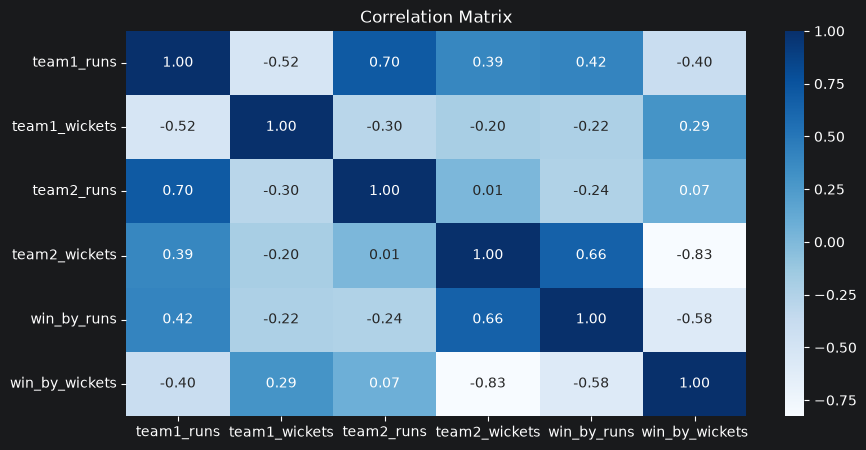

In [6]:
import seaborn as sb
correlation=x.corr()
plt.figure(figsize=(10,5))
sb.heatmap(correlation, annot=True, cmap="Blues",fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [10]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)
x_scaled[:5]

array([[-1.48275466, -0.57237672, -0.93490489, -0.70387888, -0.61995945,
         0.91096577],
       [-0.22132228, -0.57237672,  0.25143488,  0.02688081, -0.61995945,
         0.29356145],
       [ 0.54650613, -1.95436525,  0.99934474, -0.33849904, -0.61995945,
         0.60226361],
       [-0.7423487 , -0.11171388, -0.21278503, -0.33849904, -0.61995945,
         0.60226361],
       [ 0.68361834, -0.11171388, -0.52226497,  0.39226065,  1.84479499,
        -0.94124718]])

In [12]:
x_scaled.mean().round(2)
x_scaled.std()

np.float64(1.0)

In [13]:
pca=PCA(n_components=2)
x_pca=pca.fit_transform(x_scaled)
pca_df=pd.DataFrame(x_pca,columns=["PC1","PC2"])
pca_df.head(10)

,PC1,PC2
0,-1.673264,-0.488633
1,-0.280574,0.528715
2,0.283096,1.992024
3,-1.058970,0.008845
4,1.732323,-0.964595
5,-1.464538,-1.798902
6,-0.722523,1.540440
7,-2.316628,-1.012784
8,0.811351,-0.861659
9,0.808567,-0.687753


In [15]:
variance=pca.explained_variance_ratio_
print(f"pc1: {variance[0]*100: .2f}%")
print(f"pc2: {variance[1]*100: .2f}%")
print("total information retained:",round(variance.sum()*100,2),"%")
variance

pc1:  48.10%
pc2:  28.64%
total information retained: 76.74 %


array([0.48097855, 0.28637271])

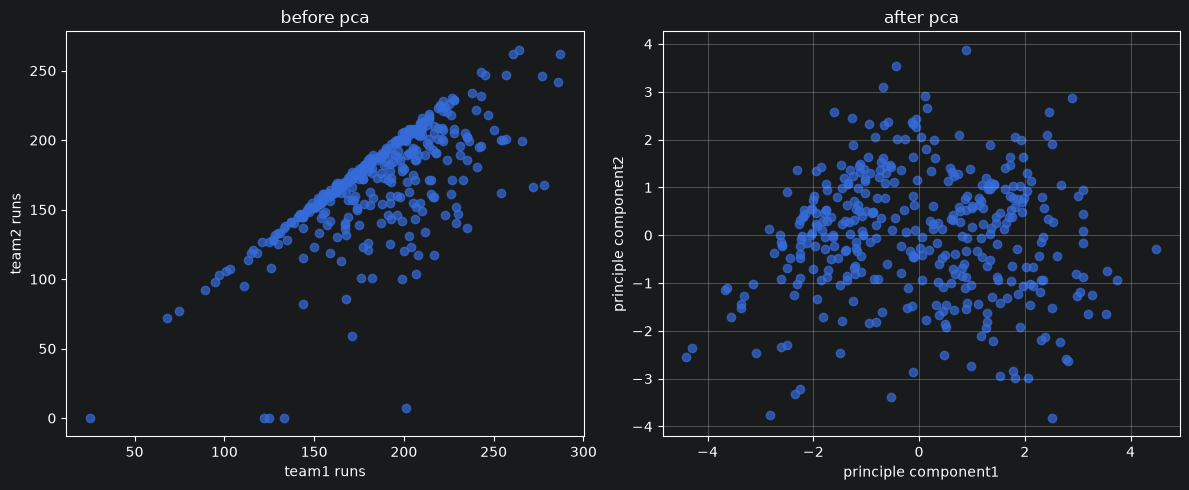

In [17]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.title("before pca")
plt.xlabel("team1 runs")
plt.ylabel("team2 runs")
plt.scatter(x["team1_runs"],x["team2_runs"],alpha=0.7)
plt.subplot(1,2,2)
plt.title("after pca")
plt.xlabel("principle component1")
plt.ylabel("principle component2")
plt.scatter(pca_df["PC1"],pca_df["PC2"],alpha=0.7)
plt.grid(True)
plt.tight_layout()
plt.show()

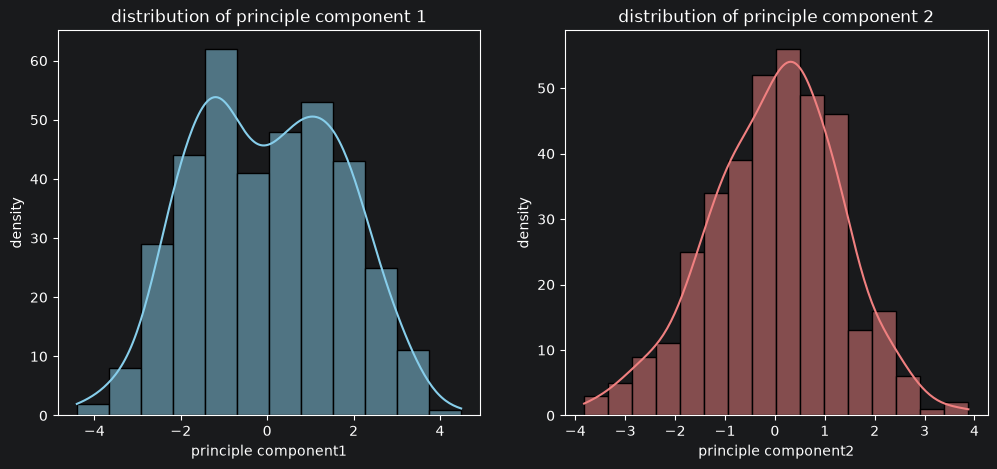

In [18]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.title("distribution of principle component 1")
plt.xlabel("principle component1")
plt.ylabel("density")
sb.histplot(pca_df["PC1"],color="skyblue",kde=True)
plt.subplot(1,2,2)
plt.title("distribution of principle component 2")
plt.xlabel("principle component2")
plt.ylabel("density")
sb.histplot(pca_df["PC2"],color="lightcoral",kde=True)
plt.show()